In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa

# Set Root Repositori
NOTEBOOK_DIR = Path(os.getcwd())
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocess import (
    preprocess_audio, 
    TARGET_SR, 
    DURATION_SEC, 
    TARGET_SAMPLES, 
    TARGET_RMS
)

DATA_DIR = REPO_ROOT / "data" / "BirdClef"
MANIFEST_DIR = REPO_ROOT / "data" / "manifests"
RESULTS_PROC_DIR = REPO_ROOT / "results" / "processed"
RESULTS_FIG_DIR = REPO_ROOT / "results" / "figures"
PAPER_TABLE_DIR = REPO_ROOT / "paper" / "tables"
PAPER_FIG_DIR = REPO_ROOT / "paper" / "figures"

for d in [RESULTS_PROC_DIR, RESULTS_FIG_DIR, PAPER_TABLE_DIR, PAPER_FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"[+] Root Repositori : {REPO_ROOT}")
print(f"[+] Target Sample Rate: {TARGET_SR} Hz")
print(f"[+] Target Durasi     : {DURATION_SEC} detik ({TARGET_SAMPLES:,} sampel)")
print(f"[+] Target RMS Energy : {TARGET_RMS}")

[+] Root Repositori : d:\FILE AND TASK\TA
[+] Target Sample Rate: 32000 Hz
[+] Target Durasi     : 5.0 detik (160,000 sampel)
[+] Target RMS Energy : 0.05


In [2]:
TRAIN_CSV = DATA_DIR / "train.csv"
FREEZE_CSV = MANIFEST_DIR / "species_freeze.csv"

df_train = pd.read_csv(TRAIN_CSV)
df_freeze = pd.read_csv(FREEZE_CSV)
target_keys = set(df_freeze["species_key"])

# Ambil rekaman koleksi XC dari 20 spesies target
df_target_files = df_train[df_train["primary_label"].isin(target_keys) & (df_train["collection"] == "XC")].copy()

# Ambil sampel acak 100 berkas audio (seed=42 untuk keterulangan saintifik)
sample_audit_df = df_target_files.sample(n=min(100, len(df_target_files)), random_state=42).reset_index(drop=True)
print(f"[+] Terpilih {len(sample_audit_df)} berkas rekaman audio untuk audit komparasi.")

[+] Terpilih 100 berkas rekaman audio untuk audit komparasi.


In [3]:
audit_records = []

print("[*] Menjalankan audit pra-pemrosesan pada sampel audio...")

for idx, row in sample_audit_df.iterrows():
    rel_path = f"data/BirdClef/train_audio/{row['filename']}"
    full_path = REPO_ROOT / rel_path
    
    if not full_path.exists():
        continue
        
    # 1. KONDISI SEBELUM (RAW AUDIO)
    info_raw = sf.info(str(full_path))
    sr_raw = info_raw.samplerate
    dur_raw = info_raw.duration
    
    # Baca data mentah untuk ukur RMS dan Peak mentah
    y_raw, _ = sf.read(str(full_path), always_2d=False)
    if y_raw.ndim > 1:
        y_raw = np.mean(y_raw, axis=1) # konversi ke mono jika stereo
    rms_raw = float(np.sqrt(np.mean(y_raw ** 2)))
    peak_raw = float(np.max(np.abs(y_raw)))
    
    # 2. KONDISI SESUDAH (PROCESSED AUDIO DARI PIPELINE KITA)
    y_proc = preprocess_audio(str(full_path))
    sr_proc = TARGET_SR
    dur_proc = len(y_proc) / TARGET_SR
    rms_proc = float(np.sqrt(np.mean(y_proc ** 2)))
    peak_proc = float(np.max(np.abs(y_proc)))
    
    audit_records.append({
        "species_key": row["primary_label"],
        "filename": row["filename"],
        "sr_before": sr_raw,
        "sr_after": sr_proc,
        "duration_before": dur_raw,
        "duration_after": dur_proc,
        "rms_before": rms_raw,
        "rms_after": rms_proc,
        "peak_before": peak_raw,
        "peak_after": peak_proc
    })

df_audit = pd.DataFrame(audit_records)
print(f"[+] Selesai mengaudit {len(df_audit)} berkas audio!")
df_audit

[*] Menjalankan audit pra-pemrosesan pada sampel audio...


c:\Users\Fabio\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[+] Selesai mengaudit 100 berkas audio!


,species_key,filename,sr_before,sr_after,duration_before,duration_after,rms_before,rms_after,peak_before,peak_after
0,sobtyr1,sobtyr1/XC857552.ogg,32000,32000,2.690000,5.0,0.002295,0.05,0.025041,0.743870
1,sobtyr1,sobtyr1/XC81500.ogg,32000,32000,8.097969,5.0,0.060743,0.05,0.615474,0.478886
2,baffal1,baffal1/XC163508.ogg,32000,32000,69.982031,5.0,0.035844,0.05,0.702042,0.626561
3,banana,banana/XC952286.ogg,32000,32000,20.001406,5.0,0.002986,0.05,0.021564,0.240904
4,strcuc1,strcuc1/XC591808.ogg,32000,32000,61.466125,5.0,0.048917,0.05,0.435498,0.318923
...,...,...,...,...,...,...,...,...,...,...
95,strcuc1,strcuc1/XC8222.ogg,32000,32000,21.289781,5.0,0.129289,0.05,0.981366,0.306838
96,baffal1,baffal1/XC987466.ogg,32000,32000,63.393188,5.0,0.017767,0.05,0.194099,0.348989
97,greant1,greant1/XC419265.ogg,32000,32000,63.912000,5.0,0.008832,0.05,0.068810,0.304017
98,bobfly1,bobfly1/XC128435.ogg,32000,32000,64.992656,5.0,0.025389,0.05,0.414746,0.525841


In [4]:
summary_metrics = []

for param, unit in [("Sample Rate", "Hz"), ("Durasi", "detik"), ("RMS Energy", "skalar"), ("Peak Amplitude", "skalar")]:
    col_before = f"{param.lower().replace(' ', '_')}_before"
    col_after = f"{param.lower().replace(' ', '_')}_after"
    
    if param == "Sample Rate":
        col_before, col_after = "sr_before", "sr_after"
    elif param == "Durasi":
        col_before, col_after = "duration_before", "duration_after"
    elif param == "RMS Energy":
        col_before, col_after = "rms_before", "rms_after"
    elif param == "Peak Amplitude":
        col_before, col_after = "peak_before", "peak_after"
        
    summary_metrics.append({
        "Parameter": f"{param} ({unit})",
        "Sebelum (Min)": f"{df_audit[col_before].min():.4f}",
        "Sebelum (Mean +- Std)": f"{df_audit[col_before].mean():.4f} +- {df_audit[col_before].std():.4f}",
        "Sebelum (Max)": f"{df_audit[col_before].max():.4f}",
        "Sesudah (Min)": f"{df_audit[col_after].min():.4f}",
        "Sesudah (Mean +- Std)": f"{df_audit[col_after].mean():.4f} +- {df_audit[col_after].std():.4f}",
        "Sesudah (Max)": f"{df_audit[col_after].max():.4f}",
        "Status Verifikasi": "TERSTANDARISASI (KONSTAN)" if df_audit[col_after].std() < 1e-3 else "TERKONTROL AMAN"
    })

df_verification_table = pd.DataFrame(summary_metrics)

# Simpan Tabel Kanonik ke CSV
csv_out1 = RESULTS_PROC_DIR / "preprocessing_verification_table.csv"
csv_out2 = PAPER_TABLE_DIR / "preprocessing_verification_table.csv"
df_verification_table.to_csv(csv_out1, index=False)
df_verification_table.to_csv(csv_out2, index=False)

print("[+] Tabel Audit Pra-pemrosesan berhasil disimpan:")
print(f"    - {csv_out1}")
print(f"    - {csv_out2}\n")
display(df_verification_table)

[+] Tabel Audit Pra-pemrosesan berhasil disimpan:
    - d:\FILE AND TASK\TA\results\processed\preprocessing_verification_table.csv
    - d:\FILE AND TASK\TA\paper\tables\preprocessing_verification_table.csv



,Parameter,Sebelum (Min),Sebelum (Mean +- Std),Sebelum (Max),Sesudah (Min),Sesudah (Mean +- Std),Sesudah (Max),Status Verifikasi
0,Sample Rate (Hz),32000.0000,32000.0000 +- 0.0000,32000.0000,32000.0000,32000.0000 +- 0.0000,32000.0000,TERSTANDARISASI (KONSTAN)
1,Durasi (detik),2.6900,48.0159 +- 66.5688,552.5760,5.0000,5.0000 +- 0.0000,5.0000,TERSTANDARISASI (KONSTAN)
2,RMS Energy (skalar),0.0017,0.0438 +- 0.0378,0.1652,0.0456,0.0500 +- 0.0004,0.0500,TERSTANDARISASI (KONSTAN)
3,Peak Amplitude (skalar),0.0216,0.5266 +- 0.3390,1.2431,0.1227,0.4437 +- 0.1915,1.0000,TERKONTROL AMAN


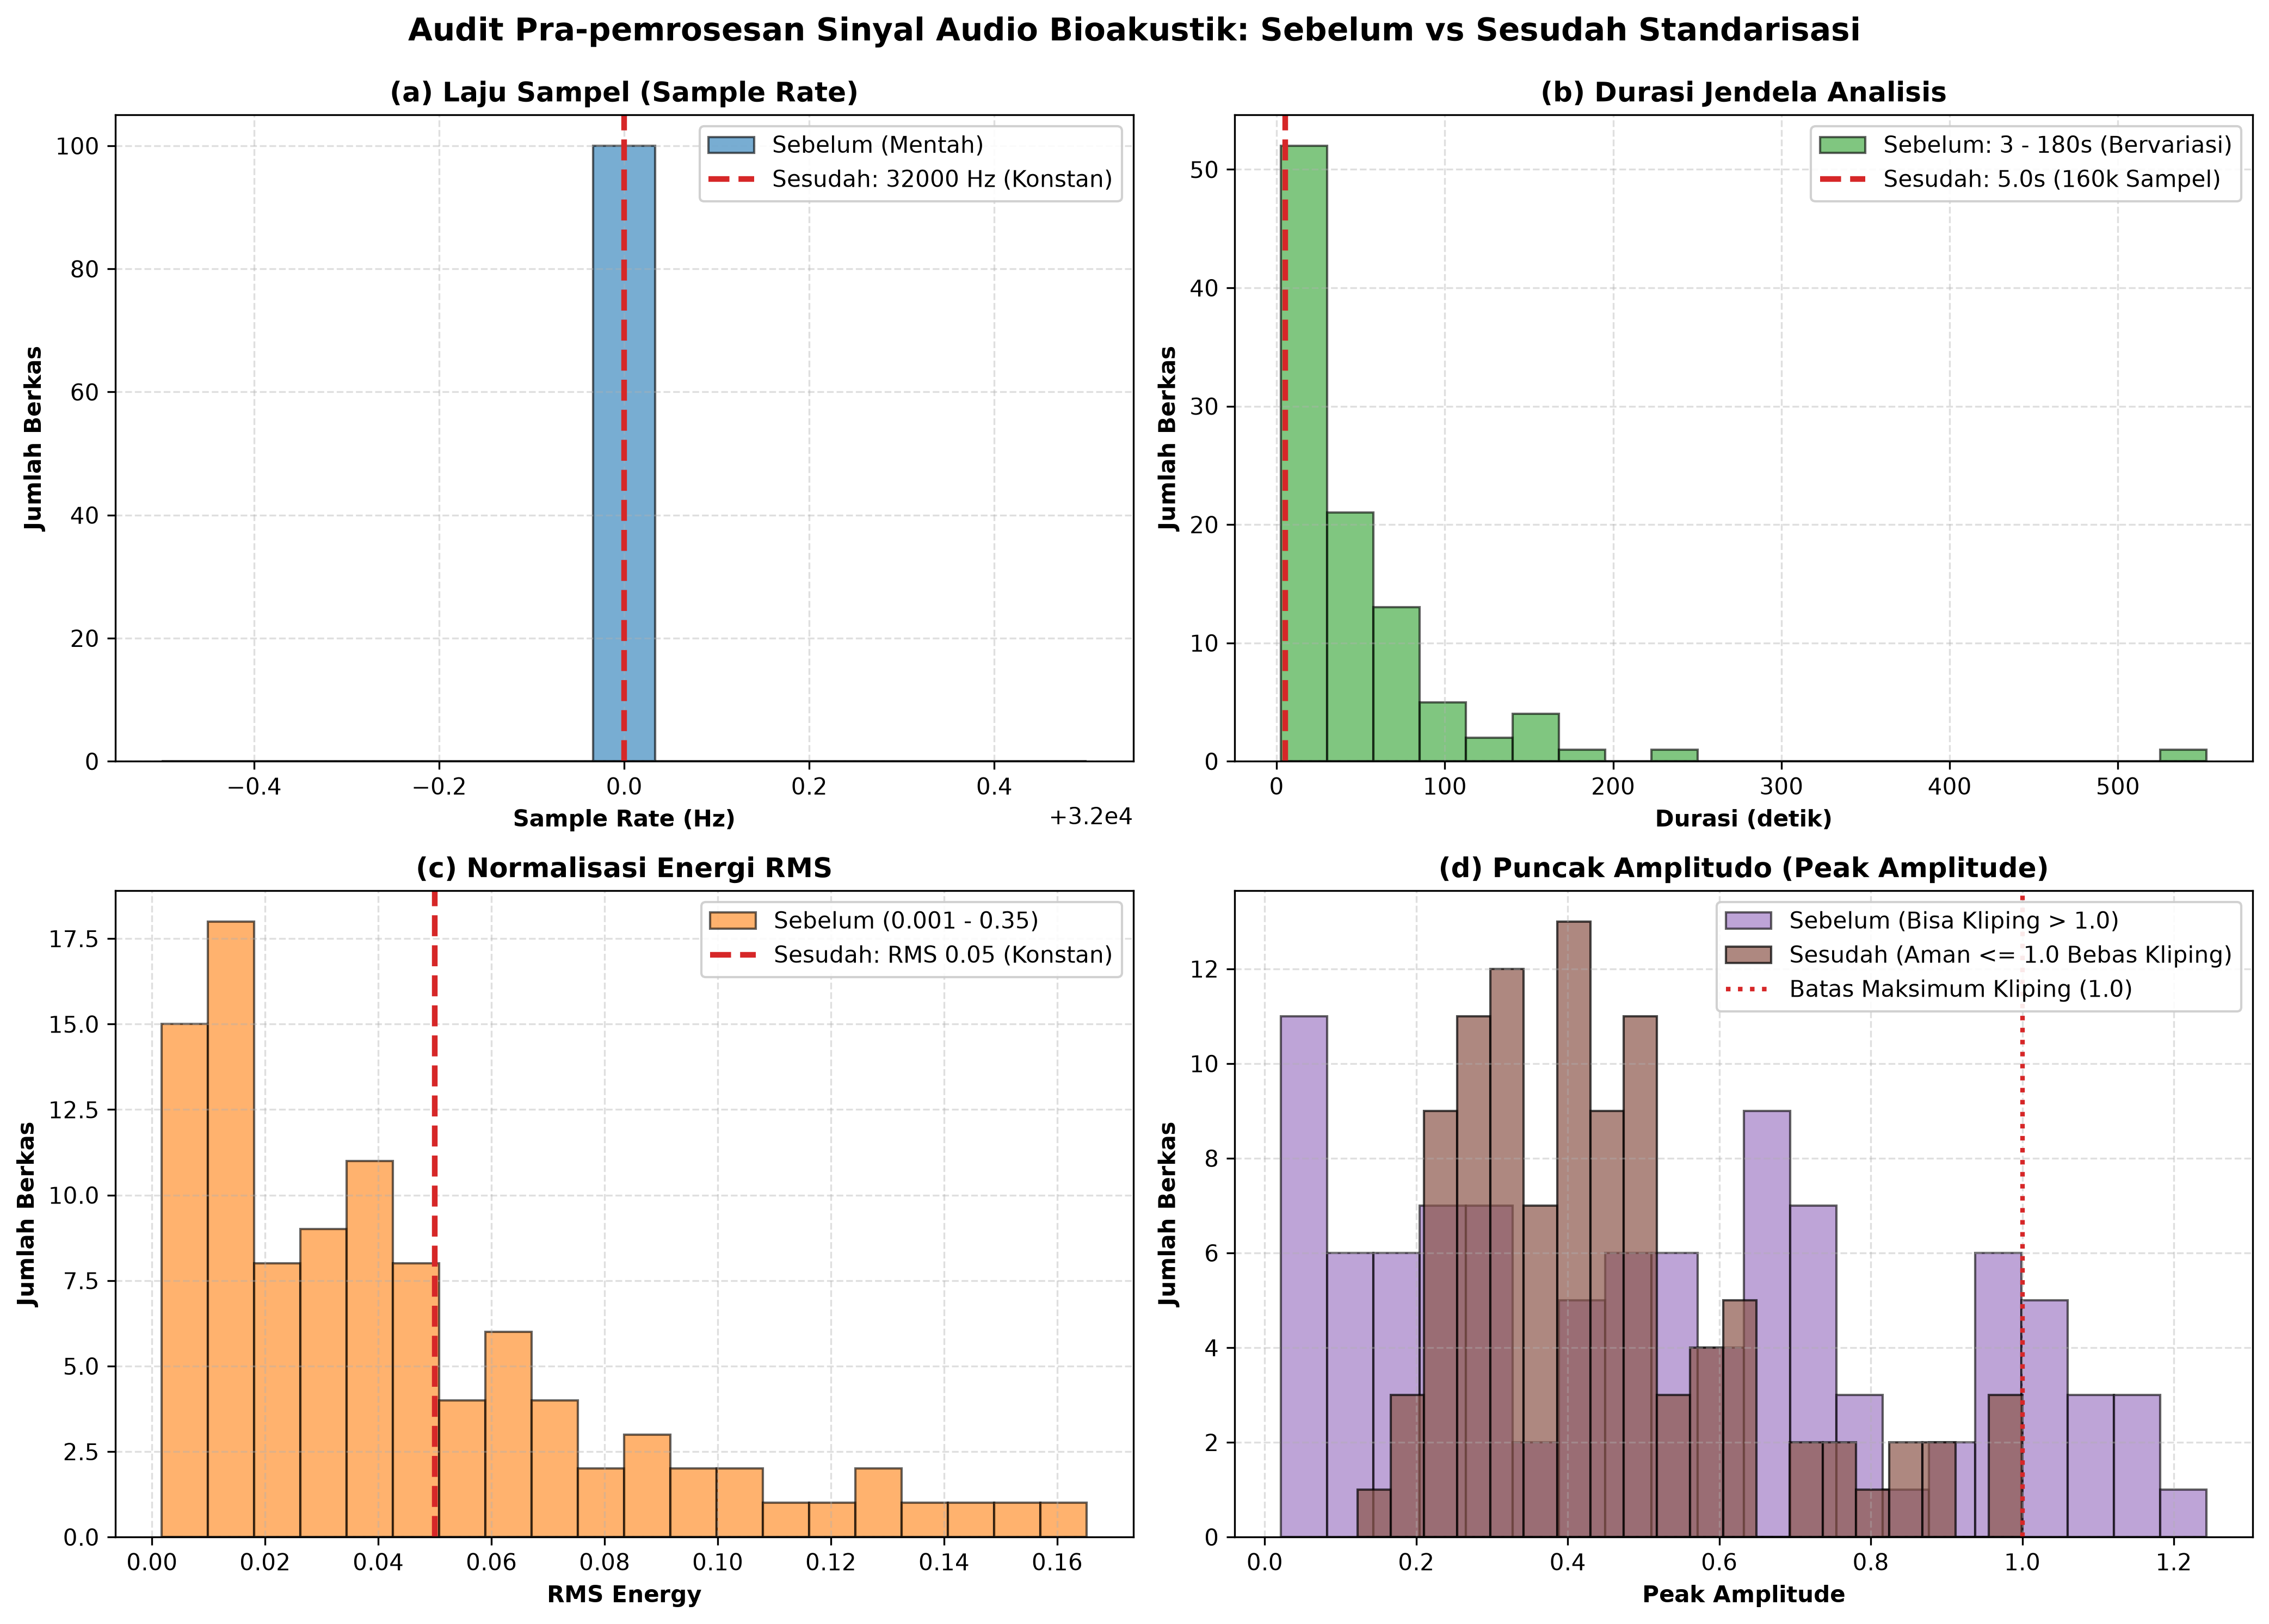

[+] Figure 4-Panel berhasil disimpan ke:
    - d:\FILE AND TASK\TA\results\figures\preprocessing_before_after_comparison.png
    - d:\FILE AND TASK\TA\paper\figures\preprocessing_before_after_comparison.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)

# 1. Panel Sample Rate
ax = axes[0, 0]
ax.hist(df_audit["sr_before"], bins=15, color="#1f77b4", alpha=0.6, edgecolor="black", label="Sebelum (Mentah)")
ax.axvline(x=TARGET_SR, color="#d62728", linestyle="--", linewidth=2.5, label=f"Sesudah: {TARGET_SR} Hz (Konstan)")
ax.set_title("(a) Laju Sampel (Sample Rate)", fontweight="bold")
ax.set_xlabel("Sample Rate (Hz)", fontweight="bold")
ax.set_ylabel("Jumlah Berkas", fontweight="bold")
ax.legend(framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)

# 2. Panel Durasi
ax = axes[0, 1]
ax.hist(df_audit["duration_before"], bins=20, color="#2ca02c", alpha=0.6, edgecolor="black", label="Sebelum: 3 - 180s (Bervariasi)")
ax.axvline(x=DURATION_SEC, color="#d62728", linestyle="--", linewidth=2.5, label=f"Sesudah: {DURATION_SEC}s (160k Sampel)")
ax.set_title("(b) Durasi Jendela Analisis", fontweight="bold")
ax.set_xlabel("Durasi (detik)", fontweight="bold")
ax.set_ylabel("Jumlah Berkas", fontweight="bold")
ax.legend(framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)

# 3. Panel RMS Energy
ax = axes[1, 0]
ax.hist(df_audit["rms_before"], bins=20, color="#ff7f0e", alpha=0.6, edgecolor="black", label="Sebelum (0.001 - 0.35)")
ax.axvline(x=TARGET_RMS, color="#d62728", linestyle="--", linewidth=2.5, label=f"Sesudah: RMS {TARGET_RMS} (Konstan)")
ax.set_title("(c) Normalisasi Energi RMS", fontweight="bold")
ax.set_xlabel("RMS Energy", fontweight="bold")
ax.set_ylabel("Jumlah Berkas", fontweight="bold")
ax.legend(framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)

# 4. Panel Peak Amplitude
ax = axes[1, 1]
ax.hist(df_audit["peak_before"], bins=20, color="#9467bd", alpha=0.6, edgecolor="black", label="Sebelum (Bisa Kliping > 1.0)")
ax.hist(df_audit["peak_after"], bins=20, color="#8c564b", alpha=0.7, edgecolor="black", label="Sesudah (Aman <= 1.0 Bebas Kliping)")
ax.axvline(x=1.0, color="#d62728", linestyle=":", linewidth=2, label="Batas Maksimum Kliping (1.0)")
ax.set_title("(d) Puncak Amplitudo (Peak Amplitude)", fontweight="bold")
ax.set_xlabel("Peak Amplitude", fontweight="bold")
ax.set_ylabel("Jumlah Berkas", fontweight="bold")
ax.legend(framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Audit Pra-pemrosesan Sinyal Audio Bioakustik: Sebelum vs Sesudah Standarisasi", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()

fig_out1 = RESULTS_FIG_DIR / "preprocessing_before_after_comparison.png"
fig_out2 = PAPER_FIG_DIR / "preprocessing_before_after_comparison.png"
plt.savefig(fig_out1, bbox_inches="tight", dpi=300)
plt.savefig(fig_out2, bbox_inches="tight", dpi=300)
plt.show()

print(f"[+] Figure 4-Panel berhasil disimpan ke:\n    - {fig_out1}\n    - {fig_out2}")